
<div align="center">

  #  **EJERCICIOS CNN**

  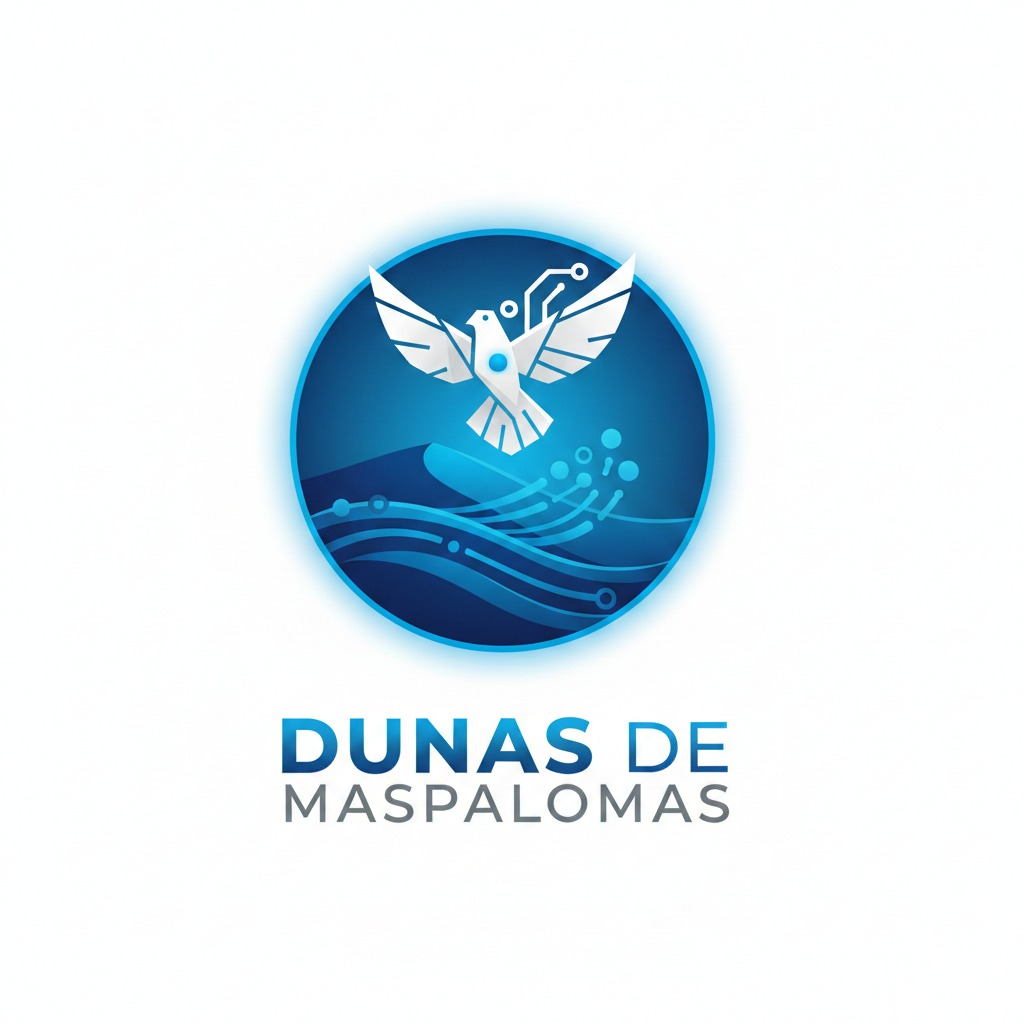
</div>

**1. Diseñar una red CNN (con la librería PyTorch) y entrenarla con el dataset
MNIST. Mostrar una imagen de prueba junto con su predicción.**

100%|██████████| 9.91M/9.91M [00:00<00:00, 35.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.20MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.7MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.84MB/s]


Época 1 completada. Último error (Loss): 0.0099
Entrenamiento finalizado en Época 1. Pérdida < 0.05


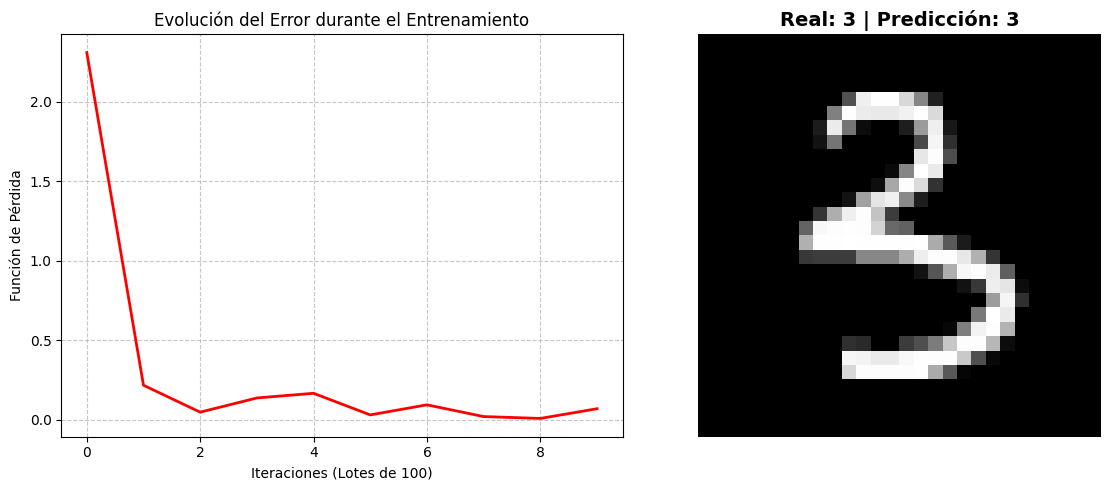

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# 1. PREPARACIÓN DE DATOS (ETL)
#Transformación: Convertir a Tensor y Normalizar
#(para que los valores estén entre 0 y 1 o -1 y 1)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) # Media 0.5, Desviación 0.5
])

#Descarga del dataset MNIST
train_set=torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_set=torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

#Carga de datos en lotes con 'DataLoaders'
train_loader=torch.utils.data.DataLoader(train_set, batch_size=64, shuffle=True)
test_loader=torch.utils.data.DataLoader(test_set, batch_size=1, shuffle=True) # Batch 1 para probar imagen a imagen luego

#2. DISEÑO DE LA RED NEURONAL (CNN)
class MiRedCNN(nn.Module):
    def __init__(self):
        super(MiRedCNN, self).__init__()
        # Capa Convolucional 1: Entrada 1 canal (gris), Salida 32 filtros, Kernel 3x3
        self.conv1=nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        # Capa Convolucional 2: Entrada 32, Salida 64 filtros
        self.conv2=nn.Conv2d(32, 64, kernel_size=3, padding=1)
        # Max Pooling (Reducción de tamaño)
        self.pool=nn.MaxPool2d(2, 2)
        # Capas lineales (Fully Connected) al final
        # Al pasar 2 veces por pool (28x28 -> 14x14 -> 7x7), el tamaño final es 7x7
        self.fc1=nn.Linear(64 * 7 * 7, 128)
        self.fc2=nn.Linear(128, 10) # 10 Salidas (Dígitos 0-9)
        self.relu=nn.ReLU()

    def forward(self, x):
        # Bloque 1: Conv -> Relu -> Pool
        x=self.pool(self.relu(self.conv1(x)))
        # Bloque 2: Conv -> Relu -> Pool
        x=self.pool(self.relu(self.conv2(x)))
        # Aplanar para pasar a vector
        x=x.view(-1, 64 * 7 * 7)
        # Clasificación
        x=self.relu(self.fc1(x))
        x=self.fc2(x)
        return x

#Generación del modelo
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
modelo=MiRedCNN().to(device)
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(modelo.parameters(), lr=0.001)

# 3. ENTRENAMIENTO
modelo.train()
epocas_max=5
objetivo_loss=0.05
historial_loss=[]
for epoca in range(epocas_max):
    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels=images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs=modelo(images)
        loss=criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # Guardamos el valor del error cada 50 iteraciones para la gráfica
        if batch_idx % 100 == 0:
            historial_loss.append(loss.item())

    print(f'Época {epoca+1} completada. Último error (Loss): {loss.item():.4f}')

    # Condición de Parada Temprana
    if loss.item() < objetivo_loss:
        print(f'Entrenamiento finalizado en Época {epoca+1}. Pérdida < 0.05')
        break

# 4. PRUEBA Y VISUALIZACIÓN DOBLE
modelo.eval()
dataiter=iter(test_loader)
images, labels=next(dataiter)
images, labels=images.to(device), labels.to(device)

output=modelo(images)
_, predicted=torch.max(output, 1)

# Gráfico doble
fig, (ax1, ax2)=plt.subplots(1, 2, figsize=(12, 5))

# Subplot 1: La curva de entrenamiento
ax1.plot(historial_loss, color='red', linewidth=2)
ax1.set_title('Evolución del Error durante el Entrenamiento')
ax1.set_xlabel('Iteraciones (Lotes de 100)')
ax1.set_ylabel('Función de Pérdida')
ax1.grid(True, linestyle='--', alpha=0.7)

# Subplot 2: La imagen real y su predicción
image_numpy = images.cpu().squeeze().numpy()
ax2.imshow(image_numpy, cmap='gray')
ax2.set_title(f'Real: {labels.item()} | Predicción: {predicted.item()}', fontsize=14, fontweight='bold')
ax2.axis('off')

plt.tight_layout()
plt.show()

**2. Lo mismo, pero con la librería Fashion-MNIST.**

In [ ]:
# 1. Cargar FashionMNIST en lugar de MNIST
train_set_f = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_set_f = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

train_loader_f = torch.utils.data.DataLoader(train_set_f, batch_size=64, shuffle=True)
test_loader_f = torch.utils.data.DataLoader(test_set_f, batch_size=1, shuffle=True)

# Etiquetas de Fashion-MNIST (para que salga texto en vez de número)
classes = ('Camiseta', 'Pantalón', 'Jersey', 'Vestido', 'Abrigo',
           'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Bota')

# 2. Re-instanciamos el modelo para entrenarlo desde cero con ropa
modelo_fashion = MiRedCNN().to(device)
optimizer_f = optim.Adam(modelo_fashion.parameters(), lr=0.001)

# 3. ENTRENAMIENTO FASHION
print("\nEntrenando con Ropa (Fashion-MNIST)...")
modelo_fashion.train()
for batch_idx, (images, labels) in enumerate(train_loader_f):
    images, labels = images.to(device), labels.to(device)
    optimizer_f.zero_grad()
    outputs = modelo_fashion(images)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer_f.step()

# 4. VISUALIZACIÓN FASHION
modelo_fashion.eval()
dataiter = iter(test_loader_f)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)

output = modelo_fashion(images)
_, predicted = torch.max(output, 1)

# Mostrar imagen
image_numpy = images.cpu().squeeze().numpy()
plt.imshow(image_numpy, cmap='gray')
plt.title(f'Real: {classes[labels.item()]} - Predicción: {classes[predicted.item()]}')
plt.axis('off')
plt.show()

100%|██████████| 26.4M/26.4M [00:01<00:00, 14.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 269kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 4.99MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 10.7MB/s]



Entrenando con Ropa (Fashion-MNIST)...


**3. Entrenar dos redes CNN diferentes (una con pocas capas y otra más profunda) sobre el dataset MNIST. Comparar la precisión de ambas.**

La red mas simple tiene 2 capas, una de convolucion y una densa.

La rede mas profunda tiene 5 capas, 3 de convoluzion y 2 densas.



In [4]:
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 1. CONFIGURACIÓN Y PREPARACIÓN DE DATOS
# Definimos una transformación: convertir imagen a Tensor y normalizarla
# La normalización ayuda a que los gradientes no oscilen demasiado (media 0.5, desv. est 0.5)
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

# Descargamos el dataset MNIST
train_set = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_set = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
test_loader = DataLoader(test_set, batch_size=1000, shuffle=False)

# --- MODELO 1: CNN SUPERFICIAL (2 capas con peso) ---
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3)
        self.fc = nn.Linear(32 * 13 * 13, 10) # Reducción tras Conv y Pool

    def forward(self, x):
        # Convolución -> Activación ReLU -> Pooling (reduce la imagen de 26x26 a 13x13)
        x = F.relu(F.max_pool2d(self.conv1(x), 2))
        x = x.view(-1, 32 * 13 * 13)
        return F.log_softmax(self.fc(x), dim=1)

# --- MODELO 2: CNN PROFUNDA (5 capas con peso) ---
class DeepCNN(nn.Module):
    def __init__(self):
        super(DeepCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3)
        self.conv2 = nn.Conv2d(32, 64, 3)
        self.conv3 = nn.Conv2d(64, 64, 3)
        self.fc1 = nn.Linear(64 * 3 * 3, 64)
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):
        x = F.relu(F.max_pool2d(self.conv1(x), 2)) # 28->26->13
        x = F.relu(F.max_pool2d(self.conv2(x), 2)) # 13->11->5
        x = F.relu(self.conv3(x))                 # 5->3
        x = x.view(-1, 64 * 3 * 3)
        x = F.relu(self.fc1(x))
        return F.log_softmax(self.fc2(x), dim=1)

# 2. Función de entrenamiento
def train(model, device, train_loader, optimizer, epoch):
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = F.nll_loss(output, target)
        loss.backward()
        optimizer.step()

# 3. Función de evaluación
def test(model, device, test_loader):
    model.eval()
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
    return 100. * correct / len(test_loader.dataset)

# Ejecución
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
models = [SimpleCNN().to(device), DeepCNN().to(device)]

for m in models:
    optimizer = optim.Adam(m.parameters(), lr=0.001)
    print(f"\nEntrenando {m.__class__.__name__}...")
    for epoch in range(1, 4): # 3 épocas para comparar rápido
        train(m, device, train_loader, optimizer, epoch)
    acc = test(m, device, test_loader)
    print(f"Precisión final: {acc}%")


Entrenando SimpleCNN...
Precisión final: 98.03%

Entrenando DeepCNN...
Precisión final: 99.09%


**4. Hacer un programa con PyTorch que descargue esta imagen https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg              la preprocese, que luego cargue la red preentrenada AlexNet y que finalmente muestre la predicción y su probabilidad.**

Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:02<00:00, 100MB/s]


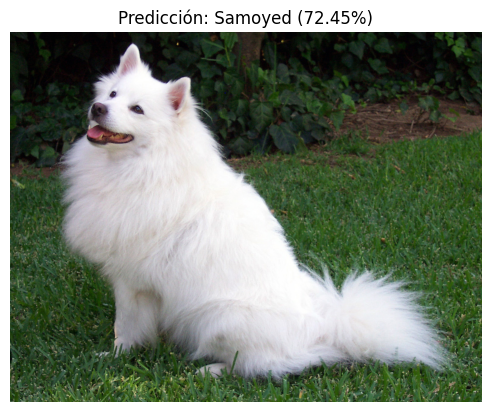

La red AlexNet está un 72.45% segura de que es un Samoyed


In [6]:
from PIL import Image
import requests
from io import BytesIO
import matplotlib.pyplot as plt
import torchvision.models as models # Importamos models de torchvision
import torch.nn.functional as F

# 1. DESCARGAR LA IMAGEN
url = "https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg"
response = requests.get(url)
img = Image.open(BytesIO(response.content))

# 2. PREPROCESAMIENTO
# AlexNet fue entrenada con imágenes de 224x224 y normalizada con valores específicos
preprocess = transforms.Compose([
    transforms.Resize(256),            # Redimensionar el lado corto a 256
    transforms.CenterCrop(224),        # Recortar el centro a 224x224
    transforms.ToTensor(),             # Convertir a tensor (0 a 1)
    transforms.Normalize(              # Normalización estándar de ImageNet
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

input_tensor = preprocess(img)
input_batch = input_tensor.unsqueeze(0) # Crear un "batch" (lote) de 1 sola imagen

# 3. CARGAR ALEXNET PREENTRENADA
# Usamos weights='DEFAULT' para obtener la versión mejorada de los pesos
model = models.alexnet(weights='DEFAULT')
model.eval() # Modo evaluación (importante: desactiva dropout)

# 4. PREDICCIÓN
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_batch = input_batch.to(device)
model.to(device)

with torch.no_grad():
    output = model(input_batch)

# 5. POST-PROCESAMIENTO (Probabilidades)
probabilities = F.softmax(output[0], dim=0)

# Descargar las etiquetas de las 1000 clases de ImageNet
labels_url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
labels = requests.get(labels_url).text.splitlines()

# Obtener el resultado con mayor probabilidad
prob, class_idx = torch.max(probabilities, 0)
label = labels[class_idx.item()]
percentage = prob.item() * 100

# 6. MOSTRAR RESULTADO
plt.imshow(img)
plt.title(f"Predicción: {label} ({percentage:.2f}%)")
plt.axis('off')
plt.show()

print(f"La red AlexNet está un {percentage:.2f}% segura de que es un {label}")